# HumanForYou - Mise en production du modele de prediction

Ce notebook simule l'utilisation reelle du modele entraine. Il repond a la question : **une fois le modele entraine, comment l'utiliser sur de nouvelles donnees RH ?**

Le pipeline complet est :
1. Charger le modele et les artefacts sauvegardes (scaler, liste des features)
2. Appliquer exactement le meme preprocessing que pendant l'entrainement
3. Calculer un score de risque de depart pour chaque employe
4. Identifier les profils prioritaires pour les equipes RH

**Important** : le scaler utilise ici est celui entraine sur X_train uniquement (notebook 03). On ne refit jamais le scaler sur de nouvelles donnees - sinon les scores ne seraient pas comparables avec ceux de l'entrainement.


## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import pickle
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RAW    = "../data/raw/"
MODELS = "../models/"
OUT    = "../outputs/"

# Seuil de decision optimise par validation croisee en notebook 04
SEUIL_OPTIMAL = 0.40


## 1. Chargement du modele et des artefacts

Trois fichiers ont ete sauvegardes a la fin de l'entrainement :
- `random_forest_final.pkl` : le modele Random Forest (500 arbres, max_depth=30)
- `feature_columns.pkl` : la liste exacte des 43 features dans le bon ordre
- `cols_norm.pkl` : la liste des colonnes a normaliser
- `scaler.pkl` : le StandardScaler ajuste sur X_train

On charge tout ca avant de toucher aux donnees.


In [2]:
with open(MODELS + "random_forest_final.pkl", "rb") as f:
    model = pickle.load(f)

with open(MODELS + "feature_columns.pkl", "rb") as f:
    feature_columns = pickle.load(f)

cols_norm = joblib.load(MODELS + "cols_norm.pkl")
scaler    = joblib.load(MODELS + "scaler.pkl")

print(f"Modele : {type(model).__name__}")
print(f"  n_estimators : {model.n_estimators}")
print(f"  max_depth    : {model.max_depth}")
print(f"  class_weight : {model.class_weight}")
print(f"\nFeatures attendues : {len(feature_columns)}")
print(f"Colonnes a normaliser : {len(cols_norm)}")
print(f"Seuil de decision : {SEUIL_OPTIMAL}  (optimise par CV en notebook 04)")


Modele : RandomForestClassifier
  n_estimators : 500
  max_depth    : 30
  class_weight : balanced

Features attendues : 43
Colonnes a normaliser : 24
Seuil de decision : 0.4  (optimise par CV en notebook 04)


## 2. Chargement des donnees

Pour utiliser ce notebook sur de nouvelles donnees, modifier les chemins ci-dessous. Le format attendu est le meme que les fichiers source originaux (HumanForYou) :
- `general_data.csv` : donnees RH generales (age, salaire, anciennete...)
- `employee_survey_data.csv` : resultats d'enquete satisfaction
- `manager_survey_data.csv` : evaluation manageriale
- `in_time.csv` / `out_time.csv` : timestamps d'entree et de sortie (badgeage)

Ici on utilise les donnees d'origine pour valider que le pipeline fonctionne.


In [3]:
# ============================================================
# MODIFIER ICI pour de nouvelles donnees
# ============================================================
NEW_GENERAL  = RAW + "general_data.csv"
NEW_SURVEY   = RAW + "employee_survey_data.csv"
NEW_MANAGER  = RAW + "manager_survey_data.csv"
NEW_IN_TIME  = RAW + "in_time.csv"
NEW_OUT_TIME = RAW + "out_time.csv"
# ============================================================

general  = pd.read_csv(NEW_GENERAL)
survey   = pd.read_csv(NEW_SURVEY)
manager  = pd.read_csv(NEW_MANAGER)
in_time  = pd.read_csv(NEW_IN_TIME,  index_col=0)
out_time = pd.read_csv(NEW_OUT_TIME, index_col=0)

# Sauvegarder la cible si elle existe (pour evaluation)
has_target = "Attrition" in general.columns
if has_target:
    y_true = (general["Attrition"] == "Yes").astype(int)

print(f"general  : {general.shape}")
print(f"survey   : {survey.shape}")
print(f"manager  : {manager.shape}")
print(f"badgeage : {in_time.shape[1]} jours de pointage")
print(f"Colonne Attrition presente : {has_target} -> {'evaluation possible' if has_target else 'pas d evaluation'}")


general  : (4410, 24)
survey   : (4410, 4)
manager  : (4410, 3)
badgeage : 261 jours de pointage
Colonne Attrition presente : True -> evaluation possible


## 3. Preprocessing

On applique exactement les memes transformations que dans le notebook 02 :
1. Suppression des 3 colonnes constantes
2. Calcul des 5 features de badgeage a partir des timestamps
3. Fusion des 4 sources sur EmployeeID
4. Imputation des valeurs manquantes par la mediane
5. Encodage (LabelEncoder + One-Hot)
6. **Normalisation avec le scaler sauvegarde** - pas de refit, on applique `.transform()` uniquement

Ce dernier point est critique : si on refitait le scaler sur les nouvelles donnees, les scores de probabilite ne seraient plus comparables avec ceux de l'entrainement.


In [4]:
# 1. Suppression colonnes constantes
for col in ["EmployeeCount", "Over18", "StandardHours", "Attrition"]:
    if col in general.columns:
        general = general.drop(columns=[col])

# 2. Features badgeage
in_dt  = in_time.apply(pd.to_datetime, errors="coerce")
out_dt = out_time.apply(pd.to_datetime, errors="coerce")
work_hours = (out_dt - in_dt).apply(lambda col: col.dt.total_seconds() / 3600)

badge = pd.DataFrame({
    "EmployeeID"       : general["EmployeeID"].values,
    "avg_hours_per_day": work_hours.mean(axis=1).values,
    "std_hours_per_day": work_hours.std(axis=1).values,
    "days_absent"      : work_hours.isna().sum(axis=1).values,
    "days_over_8h"     : (work_hours > 8).sum(axis=1).values,
    "avg_arrival_hour" : in_dt.apply(
        lambda col: col.dt.hour + col.dt.minute / 60).mean(axis=1).values,
})

# 3. Fusion
df = general.merge(survey,  on="EmployeeID", how="left")
df = df.merge(manager, on="EmployeeID", how="left")
df = df.merge(badge,   on="EmployeeID", how="left")

employee_ids = df["EmployeeID"].copy()

# 4. Imputation mediane
for col in df.select_dtypes(include="number").columns:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# 5. Encodage
le = LabelEncoder()
if "Gender" in df.columns:
    df["Gender"] = le.fit_transform(df["Gender"])

ohe_cols = ["BusinessTravel", "Department", "EducationField", "JobRole", "MaritalStatus"]
df = pd.get_dummies(df, columns=[c for c in ohe_cols if c in df.columns], drop_first=True)

# Alignement des colonnes (au cas ou certaines modalites sont absentes des nouvelles donnees)
X = df.drop(columns=["EmployeeID"], errors="ignore")
for col in feature_columns:
    if col not in X.columns:
        X[col] = 0
X = X[feature_columns]

# 6. Normalisation avec le scaler de l'entrainement (transform uniquement, pas fit)
cols_to_scale = [c for c in cols_norm if c in X.columns]
X = X.copy()
X[cols_to_scale] = scaler.transform(X[cols_to_scale])

print(f"Donnees pret : {X.shape[0]} employes, {X.shape[1]} features")
print(f"Colonnes dans l'ordre attendu : {list(X.columns) == feature_columns}")


Donnees pret : 4410 employes, 43 features
Colonnes dans l'ordre attendu : True


## 4. Scores de risque de depart

Pour chaque employe, le modele calcule une **probabilite de depart** entre 0 et 1.
On classe ensuite chaque employe en 3 niveaux de risque :
- **Risque eleve** : probabilite >= 0.40 (seuil CV-optimal) -> action RH prioritaire
- **Risque modere** : probabilite entre 0.20 et 0.40 -> a surveiller
- **Risque faible** : probabilite < 0.20 -> pas d'action immediate

Le seuil de 0.40 a ete choisi par validation croisee sur X_train (notebook 04). Il maximise le F1 tout en minimisant les faux negatifs (partants non detectes).


In [5]:
y_proba = model.predict_proba(X)[:, 1]
y_pred  = (y_proba >= SEUIL_OPTIMAL).astype(int)

def niveau_risque(p):
    if p >= SEUIL_OPTIMAL: return "Risque eleve"
    if p >= 0.20:           return "Risque modere"
    return "Risque faible"

resultats = pd.DataFrame({
    "EmployeeID"        : employee_ids.values,
    "Score_risque"      : y_proba.round(4),
    "Niveau_risque"     : [niveau_risque(p) for p in y_proba],
    "Alerte_RH"         : ["OUI" if p == 1 else "non" for p in y_pred],
})

n_alerte  = (y_pred == 1).sum()
n_modere  = ((y_proba >= 0.20) & (y_proba < SEUIL_OPTIMAL)).sum()
n_faible  = (y_proba < 0.20).sum()

print(f"Total employes analyses : {len(resultats)}")
print(f"  Risque eleve (alerte RH)  : {n_alerte:>4} ({n_alerte/len(resultats)*100:.1f}%)")
print(f"  Risque modere (surveiller): {n_modere:>4} ({n_modere/len(resultats)*100:.1f}%)")
print(f"  Risque faible             : {n_faible:>4} ({n_faible/len(resultats)*100:.1f}%)")
print()
print("Top 10 profils les plus a risque :")
print(resultats.sort_values("Score_risque", ascending=False).head(10).to_string(index=False))


Total employes analyses : 4410
  Risque eleve (alerte RH)  :  705 (16.0%)
  Risque modere (surveiller):   29 (0.7%)
  Risque faible             : 3676 (83.4%)

Top 10 profils les plus a risque :
 EmployeeID  Score_risque Niveau_risque Alerte_RH
        474         0.990  Risque eleve       OUI
       1016         0.984  Risque eleve       OUI
       3414         0.980  Risque eleve       OUI
        635         0.980  Risque eleve       OUI
       1944         0.976  Risque eleve       OUI
       4048         0.974  Risque eleve       OUI
       3575         0.974  Risque eleve       OUI
       2486         0.972  Risque eleve       OUI
       2105         0.972  Risque eleve       OUI
       1384         0.972  Risque eleve       OUI


## 5. Evaluation (si la colonne Attrition est disponible)

Quand on dispose de la reponse reelle (qui est effectivement parti), on peut mesurer les performances du modele sur ce jeu de donnees. C'est utile pour valider que le modele se generalise bien.


=== Evaluation sur les donnees fournies ===
Seuil utilise : 0.4

              precision    recall  f1-score   support

   Reste (0)       1.00      1.00      1.00      3699
    Part (1)       1.00      0.99      1.00       711

    accuracy                           1.00      4410
   macro avg       1.00      1.00      1.00      4410
weighted avg       1.00      1.00      1.00      4410

AUC-ROC : 0.9998

Matrice : TP=705 | FP=0 | FN=6 | TN=3699
Partants detectes : 705/711 (99.2%)
Faux positifs     : 0 employes signales a tort


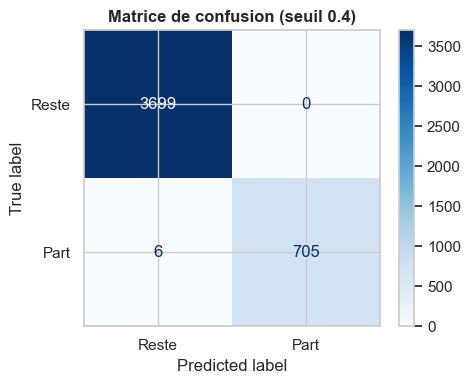

In [6]:
if has_target:
    print("=== Evaluation sur les donnees fournies ===")
    print(f"Seuil utilise : {SEUIL_OPTIMAL}")
    print()
    print(classification_report(y_true, y_pred, target_names=["Reste (0)", "Part (1)"]))
    print(f"AUC-ROC : {roc_auc_score(y_true, y_proba):.4f}")

    tn, fp, fn, tp = __import__('sklearn.metrics', fromlist=['confusion_matrix']).confusion_matrix(y_true, y_pred).ravel()
    print(f"\nMatrice : TP={tp} | FP={fp} | FN={fn} | TN={tn}")
    print(f"Partants detectes : {tp}/{tp+fn} ({tp/(tp+fn)*100:.1f}%)")
    print(f"Faux positifs     : {fp} employes signales a tort")

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=["Reste", "Part"],
        cmap="Blues", ax=ax
    )
    ax.set_title(f"Matrice de confusion (seuil {SEUIL_OPTIMAL})", fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT + "confusion_prediction.png", bbox_inches="tight")
    plt.show()
else:
    print("Pas de colonne Attrition dans les donnees -> pas d evaluation.")
    print("Les scores de risque sont disponibles dans le tableau ci-dessus.")


## 6. Export des resultats

Le fichier de sortie contient pour chaque employe :
- son `EmployeeID`
- son `Score_risque` (probabilite entre 0 et 1)
- son `Niveau_risque` (eleve / modere / faible)
- un flag `Alerte_RH` (OUI / non) pour filtrer rapidement les cas prioritaires


Fichier exporte : ../outputs/predictions_soutenance.csv
Colonnes : ['EmployeeID', 'Score_risque', 'Niveau_risque', 'Alerte_RH']



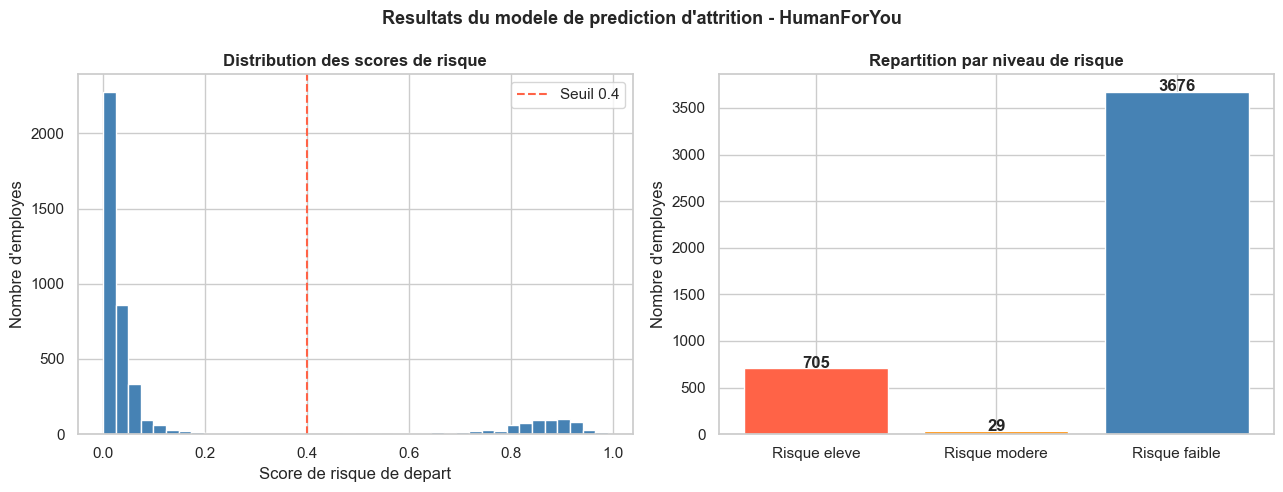

In [7]:
import os
os.makedirs(OUT, exist_ok=True)

resultats.to_csv(OUT + "predictions_soutenance.csv", index=False)
print(f"Fichier exporte : {OUT}predictions_soutenance.csv")
print(f"Colonnes : {list(resultats.columns)}")
print()

# Visualisation de la distribution des scores
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(y_proba, bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(SEUIL_OPTIMAL, color="tomato", linestyle="--", label=f"Seuil {SEUIL_OPTIMAL}")
axes[0].set_xlabel("Score de risque de depart")
axes[0].set_ylabel("Nombre d'employes")
axes[0].set_title("Distribution des scores de risque", fontweight="bold")
axes[0].legend()

niveaux = resultats["Niveau_risque"].value_counts().reindex(
    ["Risque eleve", "Risque modere", "Risque faible"])
colors = ["tomato", "darkorange", "steelblue"]
axes[1].bar(niveaux.index, niveaux.values, color=colors)
axes[1].set_title("Repartition par niveau de risque", fontweight="bold")
axes[1].set_ylabel("Nombre d'employes")
for i, v in enumerate(niveaux.values):
    axes[1].text(i, v + 10, str(v), ha="center", fontweight="bold")

plt.suptitle("Resultats du modele de prediction d'attrition - HumanForYou",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(OUT + "distribution_scores_risque.png", bbox_inches="tight")
plt.show()
